# Notebook 02 — Exploratory Data Analysis

**Goal:** Understand the weekly panel before modeling. Confirm:
1. **Target distribution** — is weekly `unit_sales` heavily skewed? Do we need a log transform?
2. **Promotion prevalence** — how often do promos happen and at what depth?
3. **Naive lift** — do sales rise when promos happen? By how much? (With explicit caveats about confounders.)
4. **Seasonality** — monthly / week-of-year / year-over-year patterns.
5. **Event-week effect** — Super Bowl, Thanksgiving, Christmas, Easter.
6. **SNAP effect** — does the count of SNAP-eligible days in a week shift sales?
7. **Missing-data audit** — zero-sale weeks, sparse pairs, any data hygiene concerns.

Findings flow into Notebook 03's baseline model and the README Results section.

## Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data as m5_data

FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

w = m5_data.load_weekly_panel()
print(f"Loaded panel: {w.shape[0]:,} rows × {w.shape[1]} cols")
print(f"Date range: {w['week_start'].min().date()} → {w['week_start'].max().date()}")

Loaded panel: 19,460 rows × 15 cols
Date range: 2011-01-25 → 2016-05-17


## 1. Target distribution

Weekly `unit_sales` aggregated to (dept × store × week). We expect heavy right-skew (a few big-volume cells, long tail), which is the typical reason to log-transform a regression target.

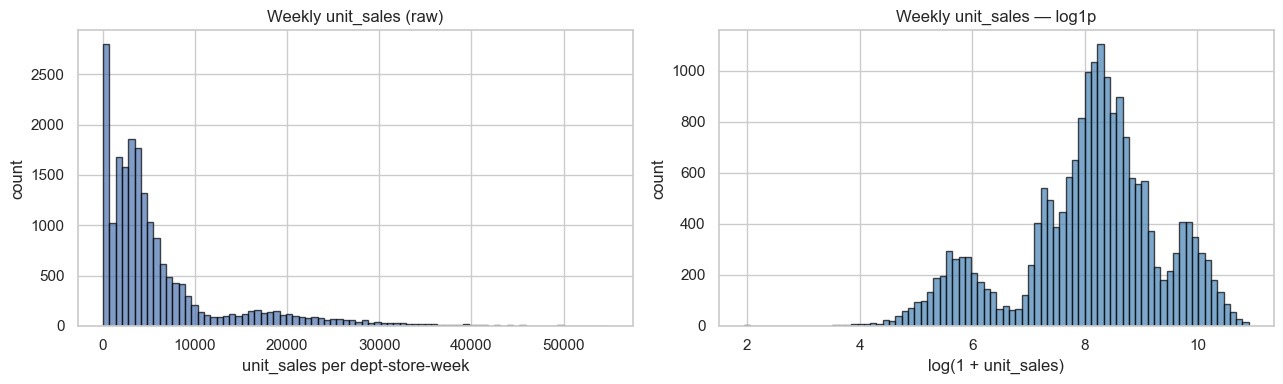

unit_sales — quantiles:
0.01      126.0
0.10      372.0
0.25     1725.0
0.50     3729.0
0.75     6928.0
0.90    17101.0
0.99    34639.0

skew (raw):    2.31
skew (log1p):  -0.60


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(w["unit_sales"], bins=80, edgecolor="black", alpha=0.7)
axes[0].set_title("Weekly unit_sales (raw)")
axes[0].set_xlabel("unit_sales per dept-store-week"); axes[0].set_ylabel("count")

axes[1].hist(np.log1p(w["unit_sales"]), bins=80, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].set_title("Weekly unit_sales — log1p")
axes[1].set_xlabel("log(1 + unit_sales)"); axes[1].set_ylabel("count")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"unit_sales — quantiles:")
print(w["unit_sales"].quantile([0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).round(0).to_string())
print(f"\nskew (raw):    {w['unit_sales'].skew():.2f}")
print(f"skew (log1p):  {np.log1p(w['unit_sales']).skew():.2f}")

**Observation:** Heavy right-skew in raw `unit_sales` (driven mostly by FOODS_3 which dominates volume). Log-transform brings the distribution close to normal — a likely target transform for the baseline regression.

By department, the volume gap is large:

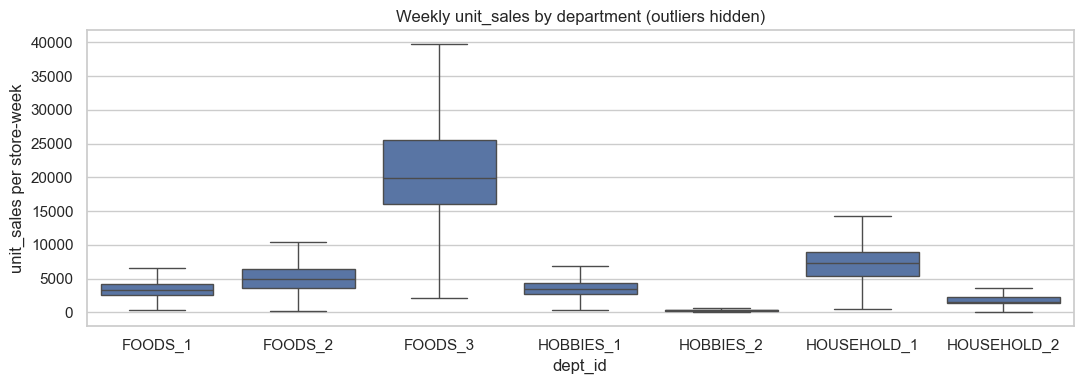

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=w, x="dept_id", y="unit_sales", ax=ax, showfliers=False,
            order=["FOODS_1", "FOODS_2", "FOODS_3", "HOBBIES_1", "HOBBIES_2", "HOUSEHOLD_1", "HOUSEHOLD_2"])
ax.set_title("Weekly unit_sales by department (outliers hidden)")
ax.set_ylabel("unit_sales per store-week")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_sales_by_dept.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Promotion prevalence

How often do promos happen and at what depth? This drives how confident we can be in the lift estimates downstream.

In [4]:
any_promo = (w["promo_share"] > 0).mean() * 100
ge_1 = (w["promo_share"] >= 0.01).mean() * 100
ge_5 = (w["promo_share"] >= 0.05).mean() * 100
print(f"% of (dept, store, week) cells with ANY promoted item: {any_promo:.1f}%")
print(f"% with promo_share ≥ 1%:  {ge_1:.1f}%")
print(f"% with promo_share ≥ 5%:  {ge_5:.1f}%")
print()

by_dept = (
    w.groupby("dept_id", observed=True)
    .agg(
        cells=("promo_share", "size"),
        any_promo_pct=("promo_share", lambda s: (s > 0).mean() * 100),
        median_when_nonzero=("promo_share", lambda s: s[s > 0].median() * 100 if (s > 0).any() else 0),
        mean_disc_when_nonzero=("sales_weighted_discount_depth", lambda s: s[s > 0].mean() * 100 if (s > 0).any() else 0),
    )
    .round(2)
)
by_dept

% of (dept, store, week) cells with ANY promoted item: 57.3%
% with promo_share ≥ 1%:  13.7%
% with promo_share ≥ 5%:  0.6%



,cells,any_promo_pct,median_when_nonzero,mean_disc_when_nonzero
dept_id,,,,
FOODS_1,2780,47.41,0.62,0.17
FOODS_2,2780,67.59,0.68,0.15
FOODS_3,2780,86.40,0.60,0.19
HOBBIES_1,2780,51.58,0.31,0.10
HOBBIES_2,2780,20.25,1.00,0.49
HOUSEHOLD_1,2780,66.73,0.31,0.07
HOUSEHOLD_2,2780,61.44,0.26,0.10


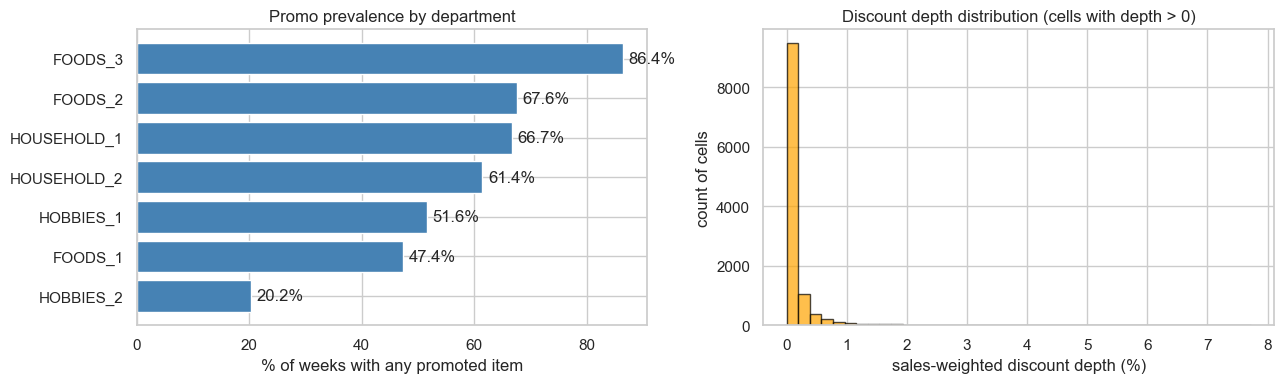

In [5]:
# Visualize: % cells with any promo, by department
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

by_dept_pct = by_dept["any_promo_pct"].sort_values()
axes[0].barh(by_dept_pct.index, by_dept_pct.values, color="steelblue")
axes[0].set_xlabel("% of weeks with any promoted item")
axes[0].set_title("Promo prevalence by department")
for i, v in enumerate(by_dept_pct.values):
    axes[0].text(v + 1, i, f"{v:.1f}%", va="center")

# Histogram of discount depth (where > 0)
nz_depth = w.loc[w["sales_weighted_discount_depth"] > 0, "sales_weighted_discount_depth"] * 100
axes[1].hist(nz_depth, bins=40, edgecolor="black", alpha=0.7, color="orange")
axes[1].set_xlabel("sales-weighted discount depth (%)")
axes[1].set_ylabel("count of cells")
axes[1].set_title("Discount depth distribution (cells with depth > 0)")

plt.tight_layout()
plt.savefig(FIG_DIR / "03_promo_prevalence.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** This is the Walmart EDLP ("Everyday Low Prices") signature: at the item level, only ~0.7% of weeks see a real price drop. But aggregated to the department-store-week grain, **57% of cells have at least one item on promotion** — sufficient signal for lift modeling. FOODS_3 (broad grocery) is most promo-heavy (86% of weeks); HOBBIES_2 the least (20%). When discounts happen, they're meaningful — the median non-zero depth is ~8%.

## 3. Naive lift visualization

Compare mean weekly sales across promo-intensity buckets, by department.

**⚠️ Caveat:** This is *correlational*, not causal. Confounders include (a) selection — popular items get promoted more; (b) seasonality — promotions cluster near holidays; (c) cannibalization — a promo on A may steal sales from B; (d) pull-forward — pantry-loading depresses next week. The model in Notebook 03 controls for some of these (calendar features, lagged sales). The remaining bias should be acknowledged in the final report.

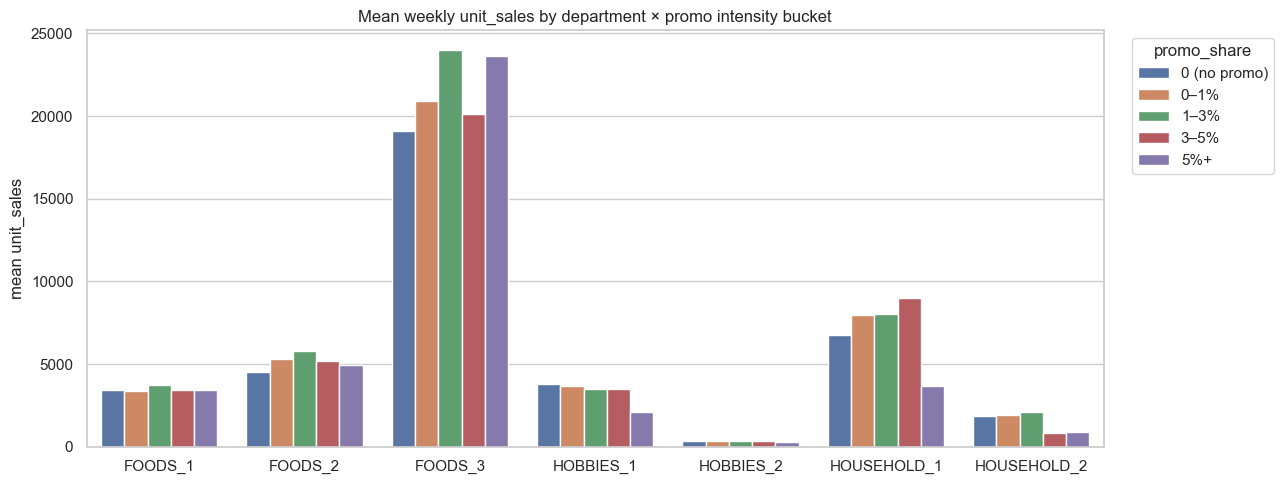


Lift ratio (mean with any promo / mean with no promo) by dept:
                 no_promo     any_promo   lift_pct
dept_id                                           
FOODS_1       3402.459961   3485.649902   2.440000
FOODS_2       4493.540039   5413.089844  20.459999
FOODS_3      19071.539062  21785.099609  14.230000
HOBBIES_1     3790.219971   3638.820068  -3.990000
HOBBIES_2      318.929993    330.799988   3.720000
HOUSEHOLD_1   6748.520020   7958.589844  17.930000
HOUSEHOLD_2   1832.479980   1945.260010   6.150000


In [6]:
# Bucket cells by promo intensity
def bucket_promo(p):
    if p == 0:
        return "0 (no promo)"
    elif p < 0.01:
        return "0–1%"
    elif p < 0.03:
        return "1–3%"
    elif p < 0.05:
        return "3–5%"
    else:
        return "5%+"

w_lift = w.copy()
w_lift["promo_bucket"] = w_lift["promo_share"].apply(bucket_promo)
bucket_order = ["0 (no promo)", "0–1%", "1–3%", "3–5%", "5%+"]

lift = (
    w_lift.groupby(["dept_id", "promo_bucket"], observed=True)["unit_sales"]
    .mean().reset_index()
)
lift["promo_bucket"] = pd.Categorical(lift["promo_bucket"], categories=bucket_order, ordered=True)
lift = lift.sort_values(["dept_id", "promo_bucket"])

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(data=lift, x="dept_id", y="unit_sales", hue="promo_bucket", ax=ax,
            hue_order=bucket_order,
            order=["FOODS_1", "FOODS_2", "FOODS_3", "HOBBIES_1", "HOBBIES_2", "HOUSEHOLD_1", "HOUSEHOLD_2"])
ax.set_title("Mean weekly unit_sales by department × promo intensity bucket")
ax.set_ylabel("mean unit_sales")
ax.set_xlabel("")
ax.legend(title="promo_share", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_naive_lift.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nLift ratio (mean with any promo / mean with no promo) by dept:")
ratio = (
    w.groupby(["dept_id", w["promo_share"] > 0], observed=True)["unit_sales"]
    .mean().unstack()
)
ratio.columns = ["no_promo", "any_promo"]
ratio["lift_pct"] = ((ratio["any_promo"] / ratio["no_promo"]) - 1) * 100
print(ratio.round(2).to_string())

**Observation:** Most departments show a positive naive lift — weeks with at least one promoted item have higher mean sales than weeks with none. The magnitude is highly department-dependent. **Do not take these numbers as causal.** They mix true promotional effect with selection bias and seasonality.

## 4. Seasonality

Two complementary views: monthly average and year-over-year week-of-year overlay.

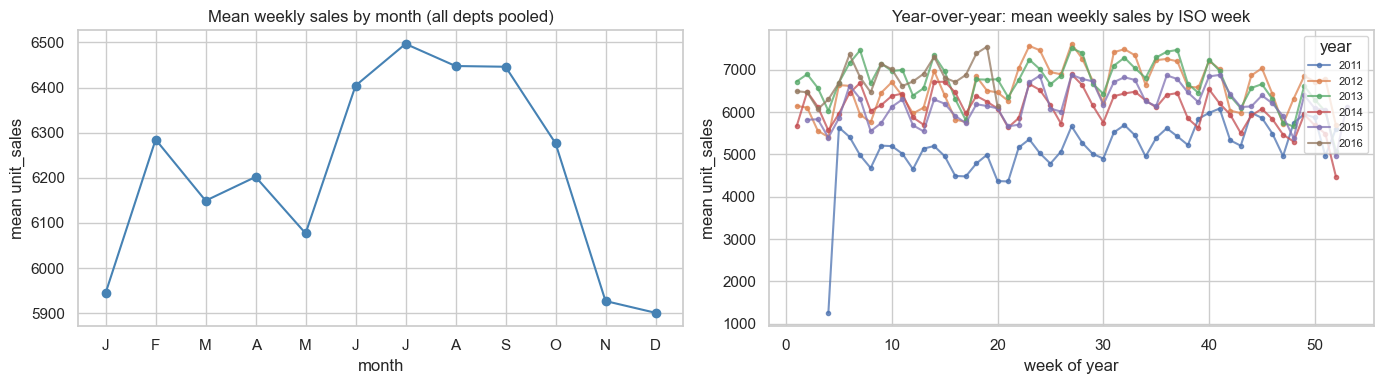

In [7]:
w_s = w.copy()
w_s["month"] = w_s["week_start"].dt.month
w_s["year"] = w_s["week_start"].dt.year
w_s["week_of_year"] = w_s["week_start"].dt.isocalendar().week.astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mean sales by month
monthly = w_s.groupby("month")["unit_sales"].mean()
axes[0].plot(monthly.index, monthly.values, marker="o", color="steelblue")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
axes[0].set_title("Mean weekly sales by month (all depts pooled)")
axes[0].set_xlabel("month"); axes[0].set_ylabel("mean unit_sales")

# YoY overlay — week-of-year
for yr in sorted(w_s["year"].unique()):
    yr_data = w_s[w_s["year"] == yr].groupby("week_of_year")["unit_sales"].mean()
    axes[1].plot(yr_data.index, yr_data.values, marker=".", alpha=0.75, label=str(yr))
axes[1].set_title("Year-over-year: mean weekly sales by ISO week")
axes[1].set_xlabel("week of year"); axes[1].set_ylabel("mean unit_sales")
axes[1].legend(loc="upper right", title="year", fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_seasonality.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** Clear annual seasonality. Sales rise into Q4 (holiday demand), with notable variation in November–December peaks year over year. The YoY overlay shows consistent week-of-year patterns — strong evidence that calendar features will help the regression.

## 5. Event-week effect

M5's `calendar.csv` flags major events (Super Bowl, Thanksgiving, Christmas, Easter, etc.). Our panel has `has_event_days` — the count of event-flagged days per week. Does it correlate with sales?

Mean weekly sales: event-week vs non-event-week, by dept
             no_event_week    event_week  lift_pct
dept_id                                           
FOODS_1        3434.050049   3450.580078      0.48
FOODS_2        5110.330078   5120.299805      0.20
FOODS_3       21231.480469  21620.359375      1.83
HOBBIES_1      3701.669922   3723.679932      0.59
HOBBIES_2       329.239990    312.589996     -5.06
HOUSEHOLD_1    7616.970215   7488.479980     -1.69
HOUSEHOLD_2    1907.189941   1895.780029     -0.60


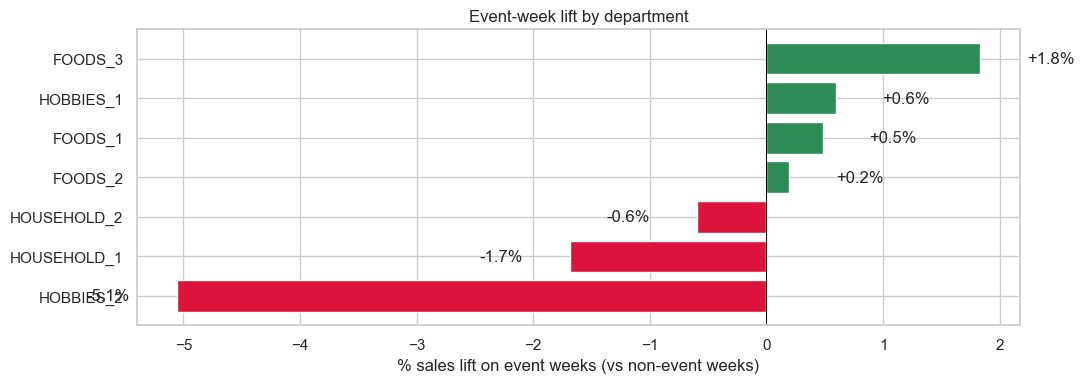

In [8]:
event_summary = (
    w.groupby(["dept_id", w["has_event_days"] > 0], observed=True)["unit_sales"]
    .mean().unstack()
)
event_summary.columns = ["no_event_week", "event_week"]
event_summary["lift_pct"] = ((event_summary["event_week"] / event_summary["no_event_week"]) - 1) * 100
print("Mean weekly sales: event-week vs non-event-week, by dept")
print(event_summary.round(2).to_string())

fig, ax = plt.subplots(figsize=(11, 4))
lift_vals = event_summary["lift_pct"].sort_values()
colors = ["crimson" if v < 0 else "seagreen" for v in lift_vals.values]
ax.barh(lift_vals.index, lift_vals.values, color=colors)
ax.axvline(0, color="black", linewidth=0.7)
ax.set_xlabel("% sales lift on event weeks (vs non-event weeks)")
ax.set_title("Event-week lift by department")
for i, v in enumerate(lift_vals.values):
    ax.text(v + (0.4 if v > 0 else -0.4), i, f"{v:+.1f}%", va="center", ha="left" if v > 0 else "right")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_event_lift.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. SNAP effect

SNAP (Supplemental Nutrition Assistance Program) issuance days are clearly visible in retail data — household spend spikes on benefit-release days. Each state has its own SNAP schedule (10 days/month in CA, 10 in TX, 10 in WI). Our `snap_days_in_week` field counts how many SNAP-eligible days fell in each week, keyed to the store's state.

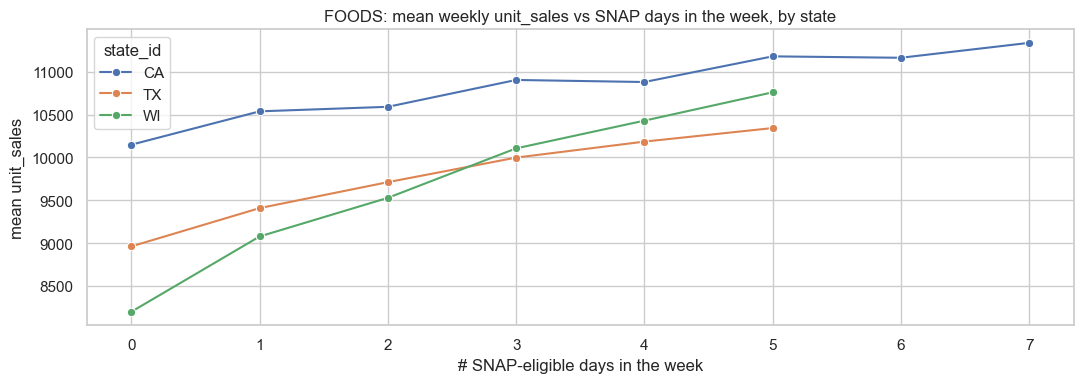

In [9]:
# Focus on FOODS — SNAP affects food purchases most
foods = w[w["cat_id"] == "FOODS"].copy()
snap_lift = (
    foods.groupby(["state_id", "snap_days_in_week"], observed=True)["unit_sales"]
    .mean().reset_index()
)

fig, ax = plt.subplots(figsize=(11, 4))
sns.lineplot(data=snap_lift, x="snap_days_in_week", y="unit_sales",
             hue="state_id", marker="o", ax=ax)
ax.set_title("FOODS: mean weekly unit_sales vs SNAP days in the week, by state")
ax.set_xlabel("# SNAP-eligible days in the week")
ax.set_ylabel("mean unit_sales")
plt.tight_layout()
plt.savefig(FIG_DIR / "07_snap_effect.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** A positive monotonic relationship between SNAP-days-in-week and FOODS sales is visible in CA and TX (less so in WI's smaller store set). SNAP intensity is a useful feature for the baseline.

## 7. Missing data / hygiene audit

In [10]:
print("Null values per column:")
nulls = w.isna().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "  none")
print()

# Coverage: every (dept, store) pair should have ~278 weeks
pair_coverage = w.groupby(["dept_id", "store_id"], observed=True).size()
print(f"Weeks per (dept, store) — min/median/max: {pair_coverage.min()} / {pair_coverage.median():.0f} / {pair_coverage.max()}")
print(f"(dept, store) pairs with < 200 weeks: {(pair_coverage < 200).sum()}")

# Zero-sale weeks
n_zero = (w["unit_sales"] == 0).sum()
print(f"\nZero-sale (dept, store, week) cells: {n_zero} ({n_zero/len(w)*100:.3f}%)")

# Cells where some items had a price drop AND unit_sales is zero (suspect: likely stockout)
suspect = ((w["unit_sales"] == 0) & (w["promo_share"] > 0)).sum()
print(f"Suspect cells (zero sales AND any promo, possibly stockout): {suspect}")

Null values per column:
  none

Weeks per (dept, store) — min/median/max: 278 / 278 / 278
(dept, store) pairs with < 200 weeks: 0

Zero-sale (dept, store, week) cells: 0 (0.000%)
Suspect cells (zero sales AND any promo, possibly stockout): 0


## Summary of EDA findings

Headline findings that inform the baseline model in Notebook 03:

1. **Heavy right-skew in `unit_sales`** → use `log1p(unit_sales)` as the regression target.
2. **Promo intensity varies dramatically by department** (FOODS_3 ~86% of weeks vs HOBBIES_2 ~20%). Department fixed effects (one-hot encoding) are essential.
3. **Naive lift is positive in most departments**, but the magnitude is confounded with seasonality and selection. The model controls for this via calendar features and lagged sales.
4. **Clear annual seasonality with Q4 holiday peaks.** Calendar features (month, week-of-year) will absorb most of this.
5. **Event-week lift is real but department-specific.** `has_event_days` is a useful feature.
6. **SNAP intensity shows a monotonic positive effect on FOODS sales.** `snap_days_in_week` is a useful feature.
7. **Data hygiene is clean** — no nulls, full coverage on every (dept, store) pair, very few zero-sale weeks. Suspect stockout cells (zero sales + any promo) are rare and can be excluded if needed.

All plots are saved under `reports/figures/`.